#Autoencoder
Topics covered:
1. Clean, well-structured Autoencoder with deeper architecture
2. Training with Adam + learning rate scheduling
3. **Reconstruction visualization**
4. **Feature Extraction** — using the encoder as a learned feature extractor
5. **Dense NN Classifier on top of AE features** vs. training on raw pixels
6. **Denoising Autoencoder** — robustness to noise
7. **Anomaly Detection** — using reconstruction error
8. **Latent Space Visualization** — t-SNE on bottleneck features

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers, callbacks
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: False


In [2]:
# ─── Hyperparameters
BATCH_SIZE    = 256
AE_EPOCHS     = 50
CLF_EPOCHS    = 30
LEARNING_RATE = 1e-3
LATENT_DIM    = 64      # bottleneck dimension
INPUT_DIM     = 784     # 28x28 flattened
NOISE_FACTOR  = 0.3     # for denoising AE

In [3]:
# ─── Load MNIST ───
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and flatten
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

x_train_flat = x_train.reshape(-1, INPUT_DIM)
x_test_flat  = x_test.reshape(-1, INPUT_DIM)

print(f"Training set : {x_train_flat.shape}, Labels: {y_train.shape}")
print(f"Test set     : {x_test_flat.shape},  Labels: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set : (60000, 784), Labels: (60000,)
Test set     : (10000, 784),  Labels: (10000,)


---
## 2. Autoencoder Architecture (Improved)

**Improvements over the original:**
- Deeper encoder/decoder (3 layers each instead of 1)
- Batch Normalization for stable training
- Sigmoid output (since pixel values are in [0,1])
- Separate `encode()` method for easy feature extraction
- Adam optimizer instead of SGD

In [4]:
class Encoder(layers.Layer):
    """Maps input → latent representation."""

    def __init__(self, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(512, activation='relu')
        self.bn1    = layers.BatchNormalization()
        self.dense2 = layers.Dense(256, activation='relu')
        self.bn2    = layers.BatchNormalization()
        self.dense3 = layers.Dense(latent_dim, activation='relu')  # bottleneck

    def call(self, x, training=False):
        x = self.bn1(self.dense1(x), training=training)
        x = self.bn2(self.dense2(x), training=training)
        x = self.dense3(x)
        return x


class Decoder(layers.Layer):
    """Maps latent representation → reconstruction."""

    def __init__(self, original_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(256, activation='relu')
        self.bn1    = layers.BatchNormalization()
        self.dense2 = layers.Dense(512, activation='relu')
        self.bn2    = layers.BatchNormalization()
        # Sigmoid ensures output is in [0, 1] matching pixel range
        self.dense3 = layers.Dense(original_dim, activation='sigmoid')

    def call(self, z, training=False):
        z = self.bn1(self.dense1(z), training=training)
        z = self.bn2(self.dense2(z), training=training)
        z = self.dense3(z)
        return z


class Autoencoder(Model):
    """Full Autoencoder = Encoder + Decoder."""

    def __init__(self, latent_dim, original_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(original_dim)

    def call(self, x, training=False):
        z = self.encoder(x, training=training)
        x_hat = self.decoder(z, training=training)
        return x_hat

    def encode(self, x):
        """Convenience method: extract latent features (inference mode)."""
        return self.encoder(x, training=False)

autoencoder = Autoencoder(latent_dim=LATENT_DIM, original_dim=INPUT_DIM)
autoencoder.build(input_shape=(None, INPUT_DIM))
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'autoencoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## 3. Training the Autoencoder

In [5]:

autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

ae_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# Train: input = output = x (unsupervised reconstruction)
ae_history = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    callbacks=ae_callbacks,
    verbose=1
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.0629 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0157 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0105 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0083 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 0.0069 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0060 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0053 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0048 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0044 - val_loss: 0.0047 - learning_rate:

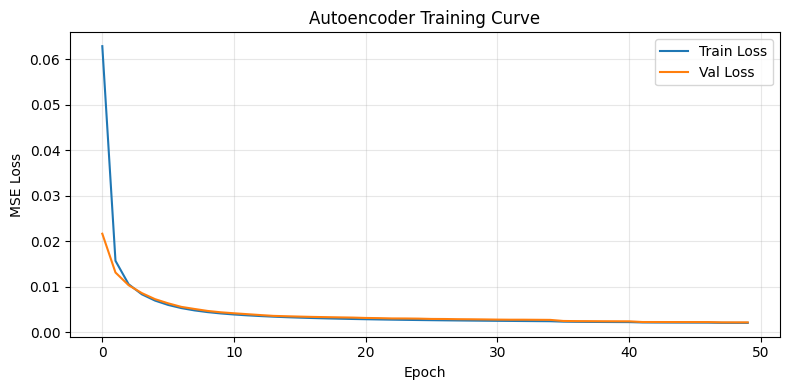

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ae_history.history['loss'], label='Train Loss')
ax.plot(ae_history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Reconstruction Visualization

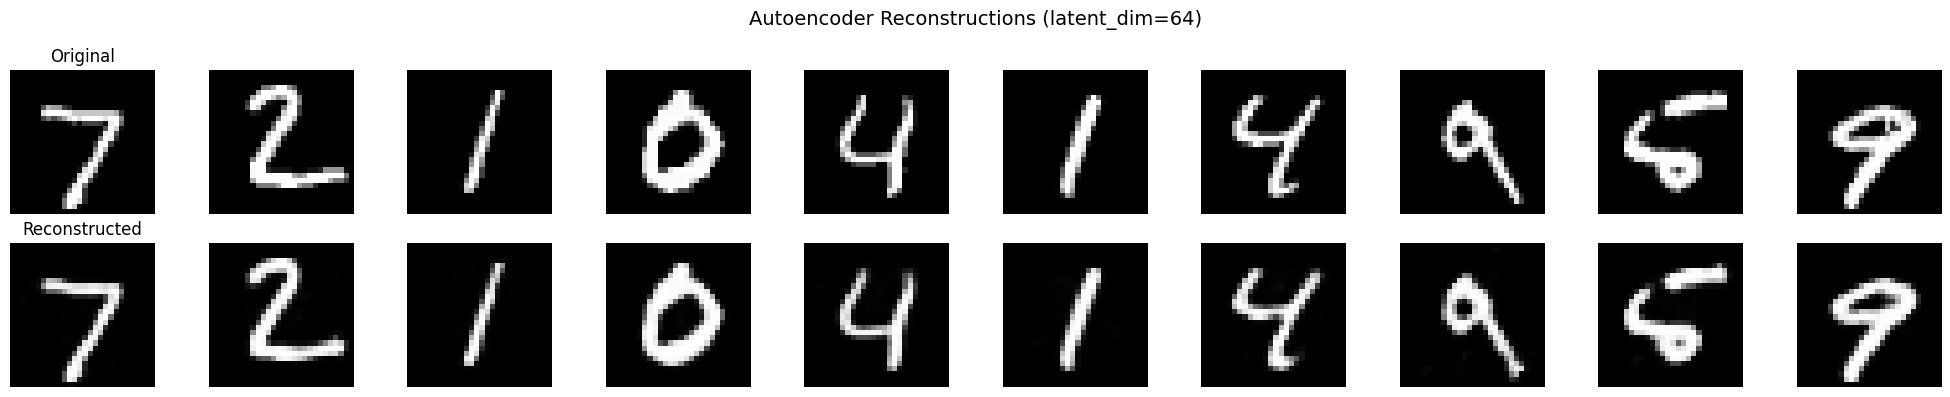

In [7]:
def plot_reconstructions(model, x_test, n=10):
    """Display original images and their reconstructions side by side."""
    x_hat = model.predict(x_test[:n], verbose=0)

    fig, axes = plt.subplots(2, n, figsize=(20, 4))
    for i in range(n):

        axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12)


        axes[1, i].imshow(x_hat[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=12)

    plt.suptitle(f'Autoencoder Reconstructions (latent_dim={LATENT_DIM})', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_reconstructions(autoencoder, x_test_flat)

---
## 5. Feature Extraction + Dense Classifier on Top

### Key Idea
The encoder learns a **compressed representation** of the data in an unsupervised way.  
We can freeze the encoder and train a small classifier on top of these features.  
This is essentially **transfer learning** — the AE does unsupervised pretraining,  
and the classifier benefits from the learned features.

We compare 3 approaches:
1. **Raw pixels → Classifier** (no AE, baseline)
2. **Frozen AE features → Classifier** (encoder weights fixed)
3. **Fine-tuned AE features → Classifier** (encoder weights trainable)

In [8]:
#Extract features using the trained encoder
z_train = autoencoder.encode(x_train_flat).numpy()
z_test  = autoencoder.encode(x_test_flat).numpy()

print(f"Raw input shape    : {x_train_flat.shape}")
print(f"Encoded feature shape: {z_train.shape}")
print(f"Compression ratio  : {INPUT_DIM / LATENT_DIM:.1f}x")

Raw input shape    : (60000, 784)
Encoded feature shape: (60000, 64)
Compression ratio  : 12.2x


In [9]:
def build_classifier(input_dim, num_classes=10):
    """Simple dense classifier."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
# ─── Approach 1: Baseline — Train classifier on RAW PIXELS ───
print("="*60)
print("APPROACH 1: Classifier on raw pixels (784-dim)")
print("="*60)

clf_raw = build_classifier(input_dim=INPUT_DIM)
hist_raw = clf_raw.fit(
    x_train_flat, y_train,
    epochs=CLF_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test_flat, y_test),
    verbose=0
)

raw_loss, raw_acc = clf_raw.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy (raw pixels): {raw_acc:.4f}")

APPROACH 1: Classifier on raw pixels (784-dim)

Test Accuracy (raw pixels): 0.9790


In [11]:
# ─── Approach 2: Classifier on FROZEN AE features ───
print("="*60)
print(f"APPROACH 2: Classifier on frozen AE features ({LATENT_DIM}-dim)")
print("="*60)

clf_frozen = build_classifier(input_dim=LATENT_DIM)
hist_frozen = clf_frozen.fit(
    z_train, y_train,
    epochs=CLF_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(z_test, y_test),
    verbose=0
)

frozen_loss, frozen_acc = clf_frozen.evaluate(z_test, y_test, verbose=0)
print(f"\nTest Accuracy (frozen AE features): {frozen_acc:.4f}")

APPROACH 2: Classifier on frozen AE features (64-dim)

Test Accuracy (frozen AE features): 0.9696


In [12]:
# ─── Approach 3: Fine-tuned — Encoder + Classifier trained end-to-end ───
print("="*60)
print("APPROACH 3: Fine-tuned encoder + classifier (end-to-end)")
print("="*60)

# Build end-to-end model: encoder → classifier head
finetune_input = layers.Input(shape=(INPUT_DIM,))
z = autoencoder.encoder(finetune_input, training=True)
x = layers.Dense(128, activation='relu')(z)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(10, activation='softmax')(x)

clf_finetune = Model(inputs=finetune_input, outputs=output)

# Use a smaller LR for the pretrained encoder layers
clf_finetune.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist_ft = clf_finetune.fit(
    x_train_flat, y_train,
    epochs=CLF_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test_flat, y_test),
    verbose=0
)

ft_loss, ft_acc = clf_finetune.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy (fine-tuned AE + classifier): {ft_acc:.4f}")

APPROACH 3: Fine-tuned encoder + classifier (end-to-end)

Test Accuracy (fine-tuned AE + classifier): 0.9787



COMPARISON SUMMARY
Approach                                        Accuracy
-------------------------------------------------------
1. Raw pixels → Classifier                        0.9790
2. Frozen AE features → Classifier                0.9696
3. Fine-tuned AE + Classifier (end-to-end)        0.9787


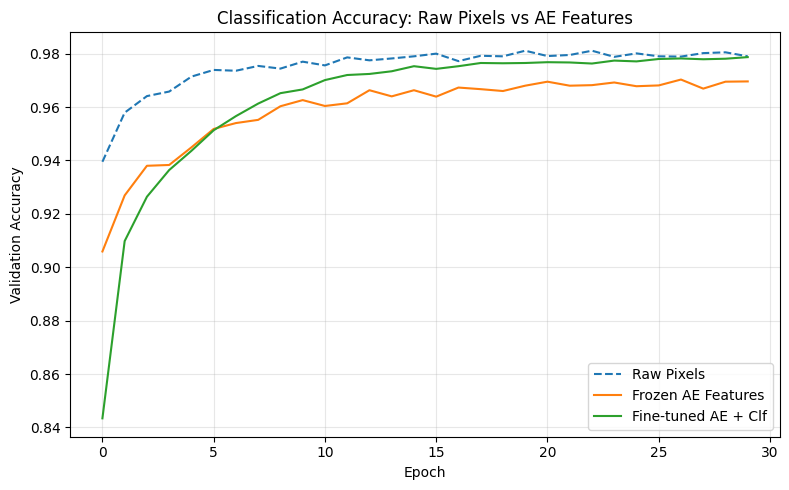

In [13]:
# ─── Compare all 3 approaches ───
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"{'Approach':<45} {'Accuracy':>10}")
print("-"*55)
print(f"{'1. Raw pixels → Classifier':<45} {raw_acc:>10.4f}")
print(f"{'2. Frozen AE features → Classifier':<45} {frozen_acc:>10.4f}")
print(f"{'3. Fine-tuned AE + Classifier (end-to-end)':<45} {ft_acc:>10.4f}")

# Plot accuracy curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_raw.history['val_accuracy'],    label='Raw Pixels', linestyle='--')
ax.plot(hist_frozen.history['val_accuracy'],  label='Frozen AE Features')
ax.plot(hist_ft.history['val_accuracy'],      label='Fine-tuned AE + Clf')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Classification Accuracy: Raw Pixels vs AE Features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Denoising Autoencoder

**Idea:** Train the AE to reconstruct *clean* images from *noisy* inputs.  
This forces the encoder to learn more robust features that capture the  
essential structure of the data rather than memorizing pixel values.

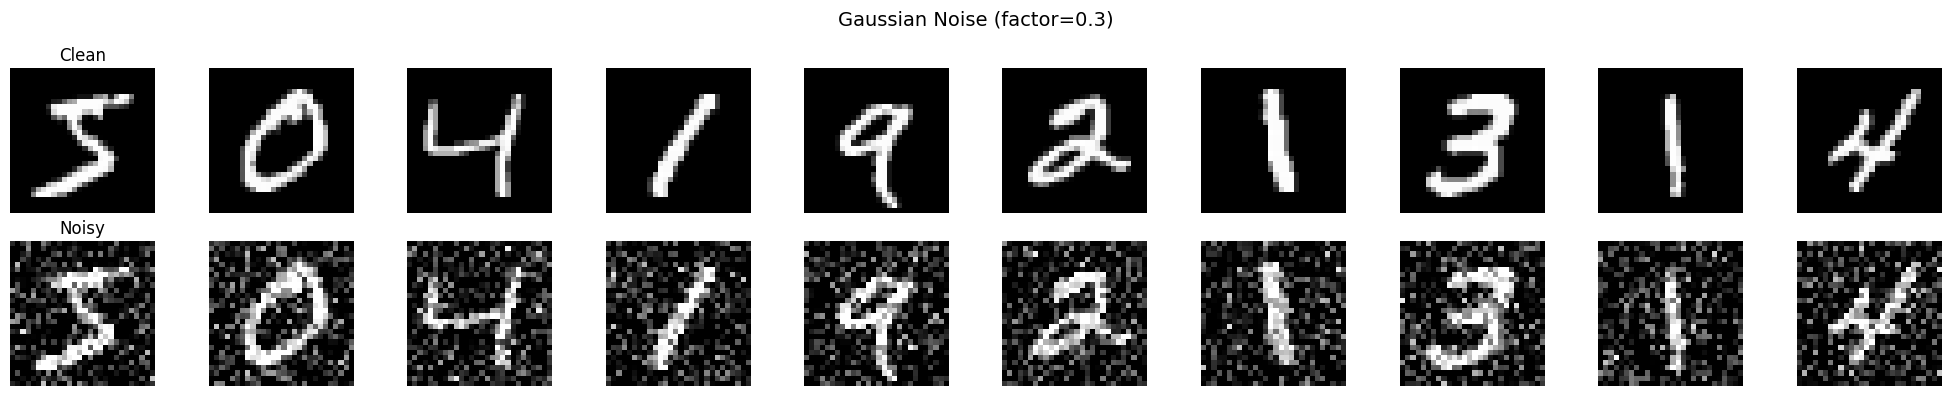

In [14]:
def add_noise(x, noise_factor=0.3):
    """Add Gaussian noise and clip to [0, 1]."""
    noise = noise_factor * np.random.normal(size=x.shape).astype(np.float32)
    return np.clip(x + noise, 0.0, 1.0)

x_train_noisy = add_noise(x_train_flat, NOISE_FACTOR)
x_test_noisy  = add_noise(x_test_flat, NOISE_FACTOR)
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(x_train_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Clean', fontsize=12)
axes[1, 0].set_title('Noisy', fontsize=12)
plt.suptitle(f'Gaussian Noise (factor={NOISE_FACTOR})', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# ─── Train Denoising AE ───
dae = Autoencoder(latent_dim=LATENT_DIM, original_dim=INPUT_DIM)
dae.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

dae_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]
dae_history = dae.fit(
    x_train_noisy, x_train_flat,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test_noisy, x_test_flat),
    callbacks=dae_callbacks,
    verbose=1
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - loss: 0.0657 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.0190 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0142 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0121 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.0108 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0098 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0092 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - loss: 0.0087 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0084 - val_loss: 0.0088 - learning_rate:

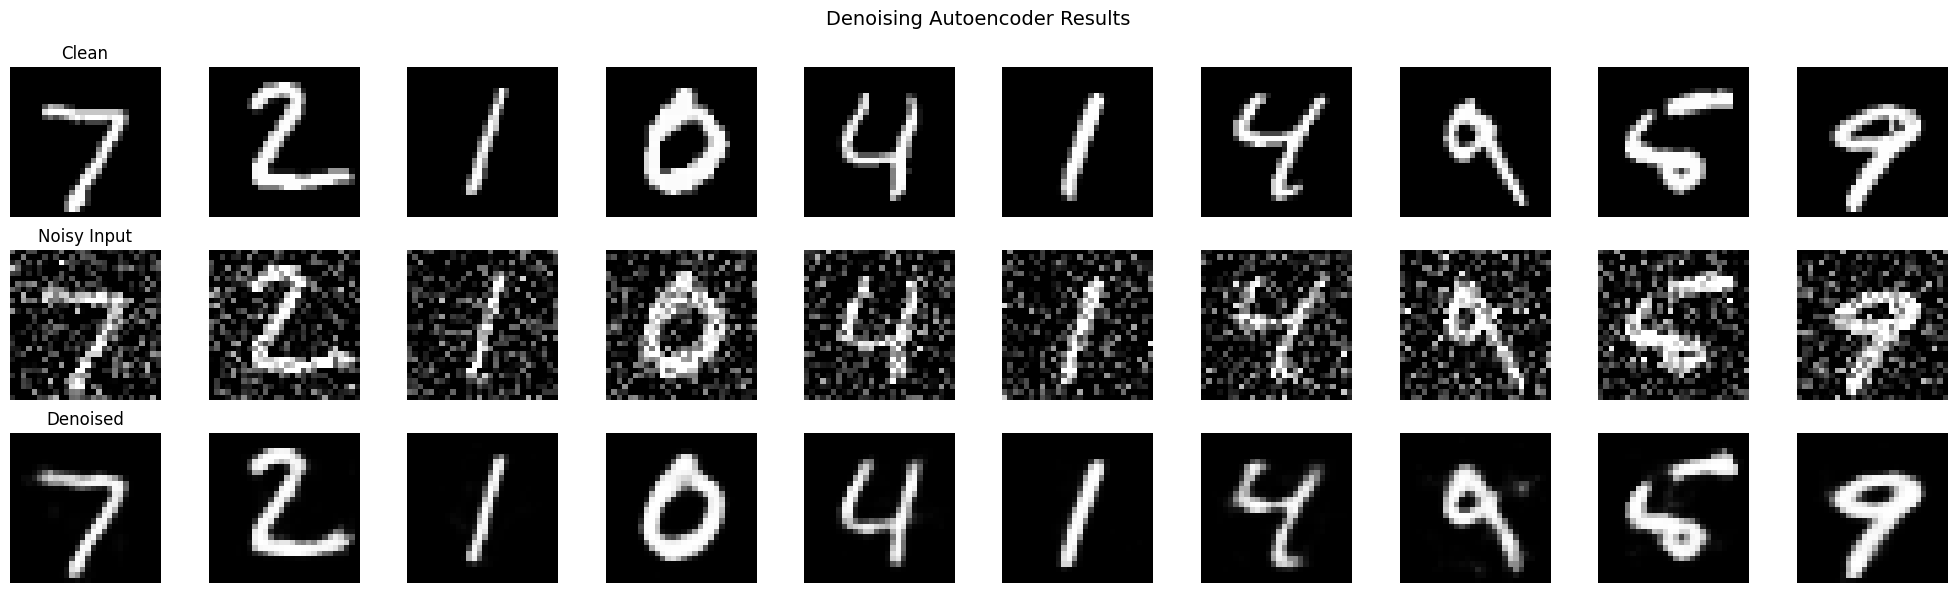

In [16]:
# ─── Visualize denoising results ───
denoised = dae.predict(x_test_noisy[:10], verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_title('Clean', fontsize=12)
axes[1, 0].set_title('Noisy Input', fontsize=12)
axes[2, 0].set_title('Denoised', fontsize=12)
plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Latent Space Visualization (t-SNE)

**Idea:** If the encoder learns meaningful features, similar digits should  
cluster together in the latent space. We use t-SNE to project the  
64-dim bottleneck features to 2D for visualization.

Running t-SNE on 5000 samples with 64-dim features...


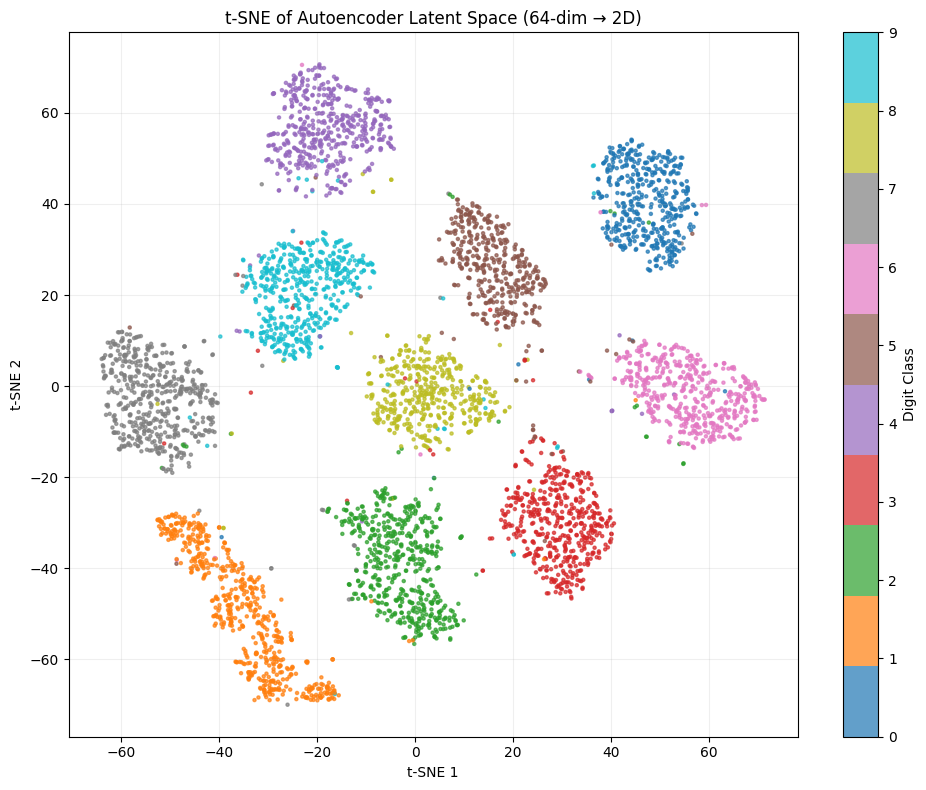

In [19]:
# Use a subset for speed (t-SNE is O(n^2))
n_vis = 5000
idx = np.random.choice(len(x_test_flat), n_vis, replace=False)

z_vis = autoencoder.encode(x_test_flat[idx]).numpy()
y_vis = y_test[idx]

print(f"Running t-SNE on {n_vis} samples with {LATENT_DIM}-dim features...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_2d = tsne.fit_transform(z_vis)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=y_vis, cmap='tab10', s=5, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit Class')
ax.set_title(f't-SNE of Autoencoder Latent Space ({LATENT_DIM}-dim → 2D)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Summary of AE Applications Demonstrated

| Application | How It Works |
|---|---|
| **Dimensionality Reduction** | Encoder compresses 784→64 dims while preserving structure |
| **Feature Extraction + Classification** | Freeze encoder, train classifier on bottleneck features |
| **Unsupervised Pretraining / Fine-tuning** | Pretrain encoder on reconstruction, then fine-tune end-to-end for classification |
| **Denoising** | Train AE to map noisy→clean; forces robust feature learning |
| **Visualization** | t-SNE on latent features reveals cluster structure |